In [14]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from google import genai
from pydantic import BaseModel, Field
from google.genai import types
import matplotlib.pyplot as plt

In [5]:
df= pd.read_csv("orthopedic_data_combined.csv")
df.shape

(103, 7)

In [6]:
df.shape

(103, 7)

In [7]:
class PatientOccupation(BaseModel):
    occupation_category: str = Field(..., description="The occupation category of the patient")
    

In [26]:
prompt = f"""
You are a data scientist working with a dataset of orthopedic patients. I will provide you with a column containing each patient's occupation, and I need you to categorize each occupation into a category. You choose the appropriate category for each occupation.So scan the occupation column first before deciding how you want to categorize them.I want up to 10 categories so try your best. Remember that i want to put this in a dataframe where the rows match the original occupations.So the total rows must be equal to 103, meaning 103 patients
."""

In [27]:
df.occupation.isna().sum()

np.int64(0)

In [ ]:
load_dotenv()
client = genai.Client()

response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=[df['occupation'].tolist(), prompt],
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=list[PatientOccupation],
        temperature=0.0,
),
)
print(response.parsed)

In [ ]:
parsed_data = response.parsed


categories_df = pd.DataFrame([item.model_dump() for item in parsed_data])

# Display the result
categories_df.head

<bound method NDFrame.head of              occupation_category
0              Services & Retail
1          Professional & Office
2    Agriculture & Skilled Labor
3                        Retired
4                        Retired
..                           ...
98         Professional & Office
99                       Retired
100            Services & Retail
101       Unemployed & Homemaker
102        Professional & Office

[103 rows x 1 columns]>

In [30]:
categories_df.head()


,occupation_category
0,Services & Retail
1,Professional & Office
2,Agriculture & Skilled Labor
3,Retired
4,Retired


In [ ]:
df['occupation_category'] = categories_df['occupation_category']
df.head()

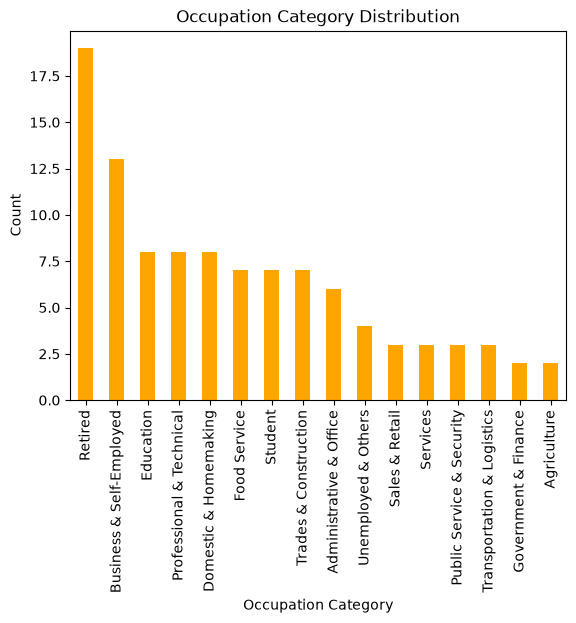

In [24]:
#plotting occupation category distribution
df['occupation_category'].value_counts().plot(kind='bar', color='orange')
plt.title('Occupation Category Distribution')
plt.xlabel('Occupation Category')
plt.ylabel('Count')
plt.show()

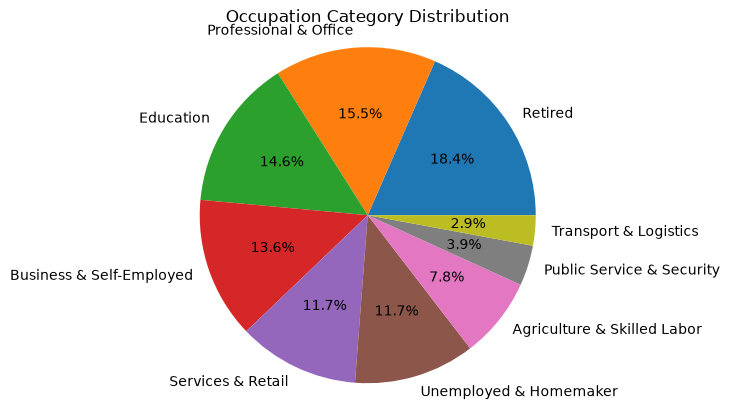

In [32]:
#plotting a pie chart for occupation category distribution
occupation_counts = df['occupation_category'].value_counts()
plt.pie(occupation_counts, labels=occupation_counts.index, autopct='%1.1f%%')
plt.title('Occupation Category Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [33]:
df.to_csv("orthopedic_data_with_occupation_categories.csv", index=False)